# Calidad y preparación general de datos

Este notebook audita la base departamento–semana utilizada por el nuevo PAA. El objetivo vigente es construir niveles estadísticos de **actividad FIRMS** a partir de `cantidad_detecciones` y luego anticiparlos con meteorología, contexto y antecedentes.

FIRMS registra anomalías térmicas o focos de calor; no confirma incendios forestales. Aquí no se crean clusters ni targets.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
RUTA = Path("data/processed/firms_open_meteo_weekly/open_meteo_firms_weekly_target_available.parquet")
datos = pd.read_parquet(RUTA)
datos["fecha_inicio_semana"] = pd.to_datetime(datos["fecha_inicio_semana"], errors="raise")
print("Dimensiones:", datos.shape)
print("Período:", datos.fecha_inicio_semana.min().date(), "a", datos.fecha_inicio_semana.max().date())

Dimensiones: (7923, 32)
Período: 2018-01-01 a 2025-12-22


## 1. Cobertura, claves y continuidad

La unidad esperada es departamento–semana. Se verifican 19 departamentos, claves únicas, 417 semanas por departamento y saltos de siete días.

In [2]:
CLAVES=["departamento","fecha_inicio_semana"]
assert len(datos)==7923 and datos.departamento.nunique()==19
assert not datos.duplicated(CLAVES).any()
assert datos.groupby("departamento").size().eq(417).all()
continuidad=datos.sort_values(CLAVES).groupby("departamento").fecha_inicio_semana.diff().dropna().dt.days
assert continuidad.eq(7).all()
pd.Series({"filas":len(datos),"departamentos":datos.departamento.nunique(),"duplicados":datos.duplicated(CLAVES).sum(),"saltos":continuidad.ne(7).sum()})

filas            7923
departamentos      19
duplicados          0
saltos              0
dtype: int64

## 2. Faltantes y rangos

Se auditan las variables candidatas. No se imputa si no existen faltantes y no se eliminan extremos válidos silenciosamente.

In [3]:
METEO=["temperature_2m_max_mean_weekly","relative_humidity_2m_min_mean_weekly","wind_speed_10m_max_mean_weekly","precipitation_sum_weekly"]
cols=CLAVES+METEO+["cantidad_detecciones"]
display(datos[cols].isna().sum().to_frame("faltantes"))
assert not datos[cols].isna().any().any()
assert datos.cantidad_detecciones.ge(0).all() and datos.precipitation_sum_weekly.ge(0).all()
assert datos.wind_speed_10m_max_mean_weekly.ge(0).all()
assert datos.relative_humidity_2m_min_mean_weekly.between(0,100).all()
datos[METEO+["cantidad_detecciones"]].describe(percentiles=[.01,.1,.25,.5,.75,.9,.95,.99]).T

,faltantes
departamento,0
fecha_inicio_semana,0
temperature_2m_max_mean_weekly,0
relative_humidity_2m_min_mean_weekly,0
wind_speed_10m_max_mean_weekly,0
precipitation_sum_weekly,0
cantidad_detecciones,0


,count,mean,std,min,1%,10%,25%,50%,75%,90%,95%,99%,max
temperature_2m_max_mean_weekly,7923.0,22.06658,5.496834,8.828571,11.502095,14.763946,17.755,21.985714,26.378061,29.36098,30.757143,33.788114,37.302041
relative_humidity_2m_min_mean_weekly,7923.0,55.064191,10.355543,21.5625,28.468536,40.538095,48.60102,56.102041,62.651927,67.815467,70.082143,74.223083,88.285714
wind_speed_10m_max_mean_weekly,7923.0,5.497973,0.876455,2.88619,3.48414,4.396952,4.922409,5.482857,6.064464,6.598027,6.949845,7.658243,9.750952
precipitation_sum_weekly,7923.0,20.757455,25.066571,0.0,0.0,0.3,2.669697,11.81875,30.341866,53.480455,70.764773,111.515007,200.35
cantidad_detecciones,7923.0,1.073836,3.143537,0.0,0.0,0.0,0.0,0.0,1.0,3.0,5.0,11.0,173.0


## 3. Distribución de `cantidad_detecciones`

Los ceros se conservan: son semanas sin detecciones FIRMS registradas. La distribución positiva se muestra por separado.

In [4]:
y=datos.cantidad_detecciones
pd.Series({"observaciones":len(y),"ceros":y.eq(0).sum(),"% ceros":y.eq(0).mean()*100,"positivas":y.gt(0).sum(),"total detecciones":y.sum(),"máximo":y.max(),"asimetría":y.skew()})

observaciones        7923.000000
ceros                4967.000000
% ceros                62.690900
positivas            2956.000000
total detecciones    8508.000000
máximo                173.000000
asimetría              26.158658
dtype: float64

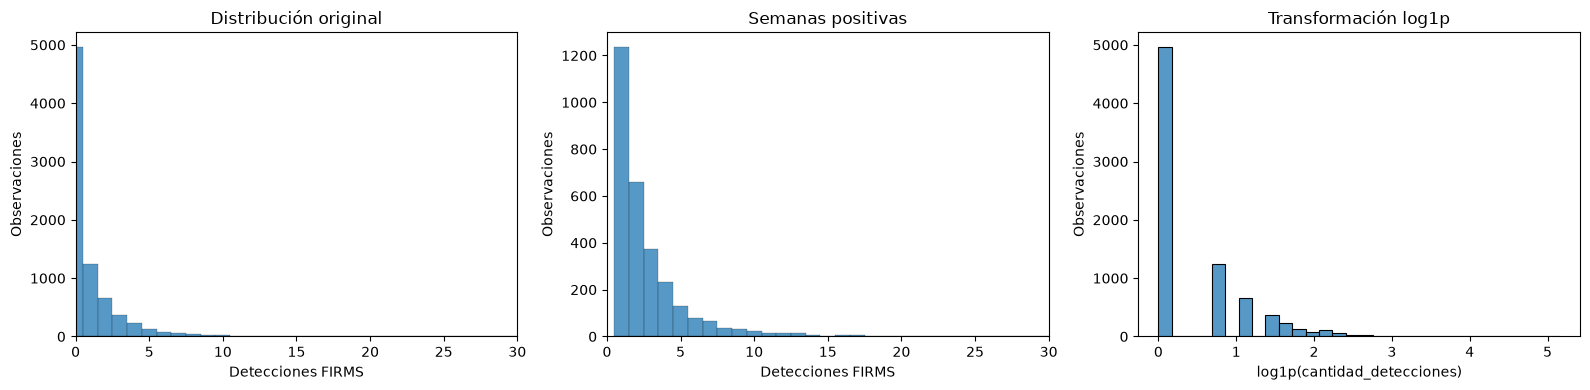

In [5]:
fig,ax=plt.subplots(1,3,figsize=(16,4))
sns.histplot(y,discrete=True,ax=ax[0]); ax[0].set(title="Distribución original",xlabel="Detecciones FIRMS",ylabel="Observaciones",xlim=(0,30))
sns.histplot(y[y.gt(0)],discrete=True,ax=ax[1]); ax[1].set(title="Semanas positivas",xlabel="Detecciones FIRMS",ylabel="Observaciones",xlim=(0,30))
sns.histplot(np.log1p(y),bins=30,ax=ax[2]); ax[2].set(title="Transformación log1p",xlabel="log1p(cantidad_detecciones)",ylabel="Observaciones")
plt.tight_layout(); plt.show()

`log1p` conserva el cero, mantiene el orden y reduce la influencia geométrica de los extremos. Su uso para K-Means se justifica en `Analisis_No_supervisado.ipynb`.

## 4. Variables meteorológicas

Se conservan como predictores candidatos. No se aprende ninguna transformación antes del split supervisado.

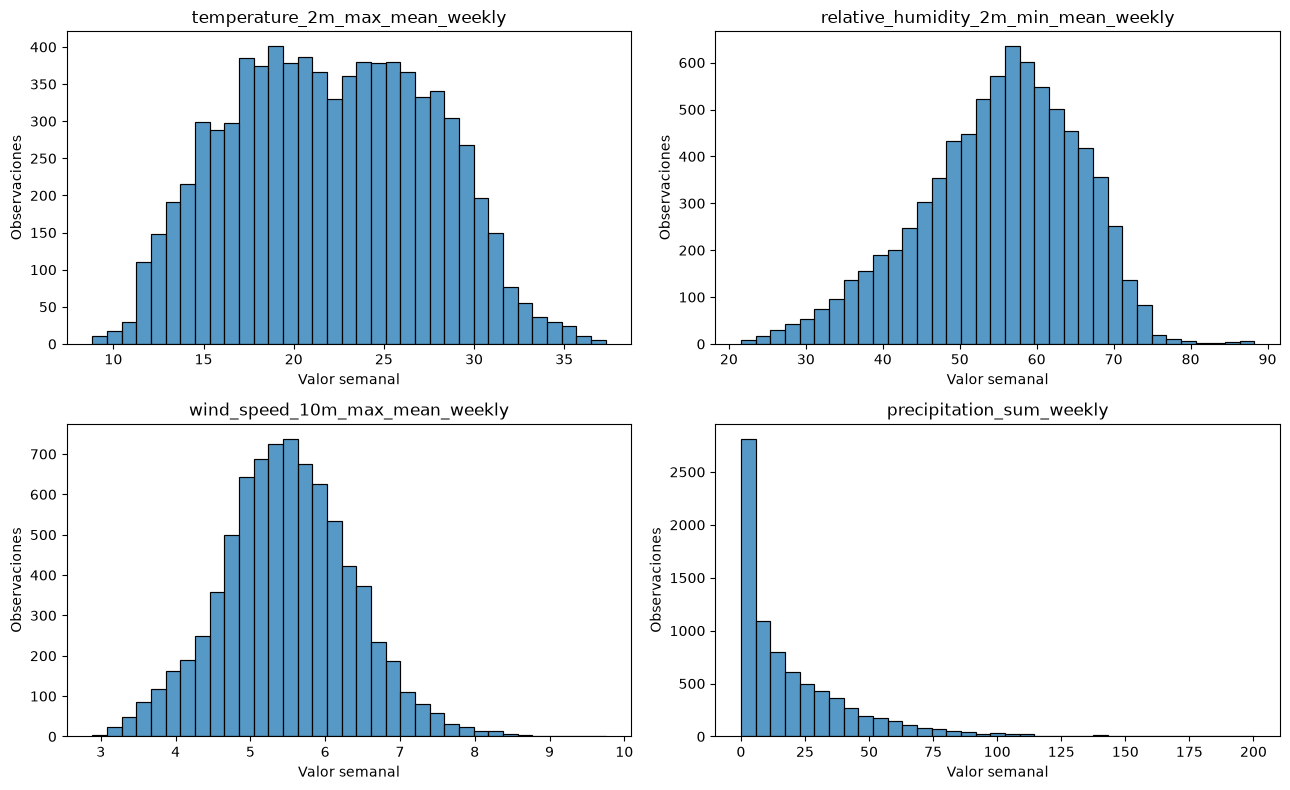

,temperature_2m_max_mean_weekly,relative_humidity_2m_min_mean_weekly,wind_speed_10m_max_mean_weekly,precipitation_sum_weekly
temperature_2m_max_mean_weekly,1.000,-0.583,-0.009,0.064
relative_humidity_2m_min_mean_weekly,-0.583,1.000,0.043,0.396
wind_speed_10m_max_mean_weekly,-0.009,0.043,1.000,0.357
precipitation_sum_weekly,0.064,0.396,0.357,1.000


In [6]:
fig,axes=plt.subplots(2,2,figsize=(13,8))
for a,v in zip(axes.ravel(),METEO): sns.histplot(datos[v],bins=35,ax=a); a.set(title=v,xlabel="Valor semanal",ylabel="Observaciones")
plt.tight_layout(); plt.show()
datos[METEO].corr(method="spearman").round(3)

## Conclusión

La base tiene cobertura completa, claves únicas y predictores sin faltantes. La masa de ceros y la asimetría requieren un tratamiento explícito. Este notebook ya no contiene clustering meteorológico, perfiles ni PCA.